# BioDose AI Exploratory Notebook

This notebook walks through a beginner-friendly drug-response analysis workflow for a synthetic cell-viability dataset.

## Learning goals

- load a CSV file with pandas
- inspect the shape and columns of the dataset
- validate the dataset before interpreting results
- calculate grouped summary statistics
- visualize dose-response behavior
- write a cautious scientific interpretation


## Biological question

Do the tested drugs show a dose-dependent reduction in cell viability, and does one drug appear stronger than the other in this synthetic example?


In [2]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.drug_analysis import (
    build_drug_response_cards,
    generate_rule_based_interpretation,
    summarize_drug_response,
)
from src.plots import create_dose_response_plot
from src.validation import validate_drug_response_df


## Load the sample dataset


In [3]:
data_path = PROJECT_ROOT / "data" / "examples" / "drug_response_sample.csv"
df = pd.read_csv(data_path)
df.head()


,sample_id,drug_name,concentration_uM,replicate,cell_viability_percent
0,S001,DrugA,0.00,1,100
1,S002,DrugA,0.00,2,98
2,S003,DrugA,0.00,3,102
3,S004,DrugA,0.01,1,96
4,S005,DrugA,0.01,2,94


## Inspect the dataset

These first checks help confirm that the file loaded correctly and that the expected columns are present.


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values by column:")
print(df.isna().sum())


Shape: (30, 5)

Columns:
['sample_id', 'drug_name', 'concentration_uM', 'replicate', 'cell_viability_percent']

Missing values by column:
sample_id                 0
drug_name                 0
concentration_uM          0
replicate                 0
cell_viability_percent    0
dtype: int64


## Validate the dataset

Before calculating results, it is good practice to look for missing values, unexpected types, or suspicious entries such as duplicate sample identifiers.


In [5]:
warnings = validate_drug_response_df(df)
warnings if warnings else ["No major data-quality warnings detected."]


['No major data-quality warnings detected.']

## Compute summary statistics

We group by `drug_name` and `concentration_uM`, then calculate the mean viability, standard deviation, replicate count, and standard error.


In [6]:
summary_df = summarize_drug_response(df)
summary_df


,drug_name,concentration_uM,mean_viability,sd_viability,n,sem_viability
0,DrugA,0.00,100.000000,2.000000,3,1.154701
1,DrugA,0.01,95.000000,1.000000,3,0.577350
2,DrugA,0.10,87.000000,2.000000,3,1.154701
3,DrugA,1.00,62.666667,2.516611,3,1.452966
4,DrugA,10.00,30.333333,2.516611,3,1.452966
5,DrugB,0.00,100.000000,1.000000,3,0.577350
6,DrugB,0.01,98.000000,1.000000,3,0.577350
7,DrugB,0.10,91.000000,1.000000,3,0.577350
8,DrugB,1.00,73.666667,1.527525,3,0.881917
9,DrugB,10.00,45.333333,1.527525,3,0.881917


## Build quick result cards

These high-level values are useful for a dashboard or report summary.


In [7]:
cards = build_drug_response_cards(df, summary_df)
cards


{'drugs_detected': 2,
 'concentrations_tested': 5,
 'total_samples': 30,
 'strongest_observed_response': 'DrugA at 10.0 uM',
 'missing_values': 0}

## Create a dose-response plot

The chart uses a log-scaled x-axis. Because zero cannot appear on a log scale, the plotting utility remaps `0` to a very small value for display while keeping the original concentration in the hover text.


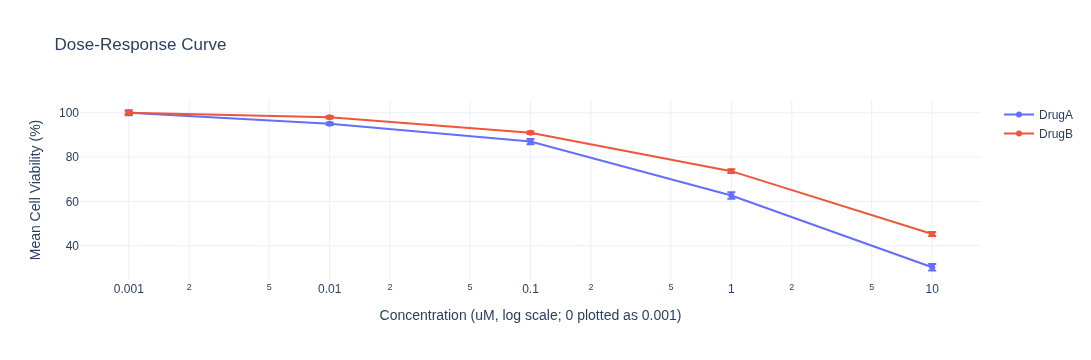

In [8]:
fig = create_dose_response_plot(summary_df)
fig


## Plain-English interpretation

This local fallback interpretation is useful when you want a cautious narrative without making an external API call.


In [9]:
print(generate_rule_based_interpretation(summary_df, warnings))


## Plain-English Summary

In this dataset, DrugA shows the strongest reduction in cell viability at the highest tested concentration.
Compared with DrugB, the response appears stronger overall for DrugA.

## Key Observations

- DrugA: mean viability changes from 100.0% to 30.3% across the tested range, a decrease of 69.7 percentage points.
- DrugB: mean viability changes from 100.0% to 45.3% across the tested range, a decrease of 54.7 percentage points.

## Possible Biological Interpretation

The pattern is consistent with a dose-dependent response in this assay, but it should be treated as an initial observation rather than a biological conclusion.

## Limitations

- This project uses summary-level analysis only and does not fit an IC50 curve.
- Replicate counts are small, so apparent differences may not be stable.
- Experimental controls and assay conditions still need manual review.

## What to Verify Manually

- Confirm that concentration units and viability units are correct.
- Ch

## Limitations

- This dataset is synthetic and for learning only.
- The first version does not fit an IC50 model.
- Small replicate counts can make differences look more certain than they really are.
- Experimental controls and assay conditions still need manual review.


## Next steps

Possible extensions for this project:

- add IC50 fitting
- compare more than two drug candidates
- include significance testing where appropriate
- connect the notebook analysis to the Gradio app and Quarto report
